# Raw QC Analysis - SNR vs Oxygen

This notebook analyzes the raw quality control data extracted from all log files within 96 hours of experiment start times.

## Dataset Overview

**Source:** `Raw_QC_Analysis_96h.csv`

**Files Analyzed:**
- 63,237 total log files (P1: 19,972 | P2: 17,281 | P3: 25,984)
- 44,139 processed (within 96h window of plate start)
- 19,095 skipped (outside 96h windows)

**Raw Data:** 3,459,411 measurements (BEFORE pipeline filtering)

### SNR Distribution (All Data)
| Range | Count | % |
|-------|-------|---|
| SNR < 0.4 | 571,245 | 16.5% |
| 0.4 ≤ SNR < 1.4 | 126,406 | 3.7% |
| 1.4 ≤ SNR < 2.0 | 85,493 | 2.5% |
| SNR ≥ 2.0 | 2,676,267 | 77.4% |

### O2 Distribution (All Data)
| Range | Count | % |
|-------|-------|---|
| O2 < 0% | 426,966 | 12.3% |
| 0% ≤ O2 ≤ 80% | 2,848,162 | 82.3% |
| O2 > 80% | 184,283 | 5.3% |

### Plate Start Times (96h windows)
- **Plate 1:** 2025-05-11 20:45:07 → 2025-05-15 20:45:07
- **Plate 2:** 2025-05-29 13:29:00 → 2025-06-02 13:29:00
- **Plate 3:** 2020-01-19 20:14:13 → 2020-01-23 20:14:13

---

## Analysis: SNR < 2.0 vs Oxygen Levels

This analysis focuses on measurements with **SNR < 2.0** to understand the relationship between poor signal quality and oxygen readings.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

In [11]:
# Cell #3
# Depends on: None

# Path discovery convention
from pathlib import Path

current_dir = Path.cwd()

if current_dir.name == 'Prediction_Models':
    PROJECT_ROOT = current_dir.parent
elif (current_dir / 'EQN_Coefficients').exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / 'EQN_Coefficients').exists():
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

# Load the raw QC data from Cleaned_Data/
csv_path = PROJECT_ROOT / 'Cleaned_Data' / 'Raw_QC_Analysis_96h.csv'
df = pd.read_csv(csv_path)

print(f"Total measurements: {len(df):,}")
print(f"SNR range: {df['snr'].min():.2f} to {df['snr'].max():.2f}")
print(f"O2 range: {df['oxygen_pct_air'].min():.1f}% to {df['oxygen_pct_air'].max():.1f}%")

df.head()

Total measurements: 3,459,411
SNR range: -1988.76 to 6897.73
O2 range: -7749635.0% to 9796958.0%


,snr,oxygen_pct_air,file_path
0,-1.0,-100.0,LogFiles\P1OxygenLogs\A01-133914692316949624.log
1,-1.0,-100.0,LogFiles\P1OxygenLogs\A01-133914692316949624.log
2,-1.0,-100.0,LogFiles\P1OxygenLogs\A01-133914692316949624.log
3,-1.0,-100.0,LogFiles\P1OxygenLogs\A01-133914692316949624.log
4,0.9,71.0,LogFiles\P1OxygenLogs\A01-133914692316949624.log


## Filter for SNR < 2.0

In [12]:
# Filter for SNR < 2.0
# Filter for SNR < 2.0, and count how many are less than -1
df_low_snr = df[df['snr'] < 2.0].copy()
between_minus1_and_2 = df_low_snr[(df_low_snr['snr'] >= -1) & (df_low_snr['snr'] < 2.0)]
less_than_minus1 = df_low_snr[df_low_snr['snr'] < -1]

print(f"Measurements with -1 ≤ SNR < 2.0: {len(between_minus1_and_2):,}")
print(f"Measurements with SNR < -1: {len(less_than_minus1):,}")

print(f"Measurements with SNR < 2.0: {len(df_low_snr):,}")
print(f"Percentage: {len(df_low_snr) / len(df) * 100:.1f}%")
print(f"\nSNR range (filtered): {df_low_snr['snr'].min():.2f} to {df_low_snr['snr'].max():.2f}")
print(f"O2 range (filtered): {df_low_snr['oxygen_pct_air'].min():.1f}% to {df_low_snr['oxygen_pct_air'].max():.1f}%")

Measurements with -1 ≤ SNR < 2.0: 782,181
Measurements with SNR < -1: 963
Measurements with SNR < 2.0: 783,144
Percentage: 22.6%

SNR range (filtered): -1988.76 to 1.99
O2 range (filtered): -7749635.0% to 9796958.0%


## Plot: SNR vs Oxygen (SNR < 2.0)

Data WITHIN plotting range (-1 ≤ SNR ≤ 2, -10 ≤ O2 ≤ 100): 291,061
Data OUTSIDE plotting range:
  - SNR < -1: 963
  - SNR > 2: 0
  - O2 < -10%: 415,772
  - O2 > 100%: 76,265
  - Total outside: 492,083 (62.8%)


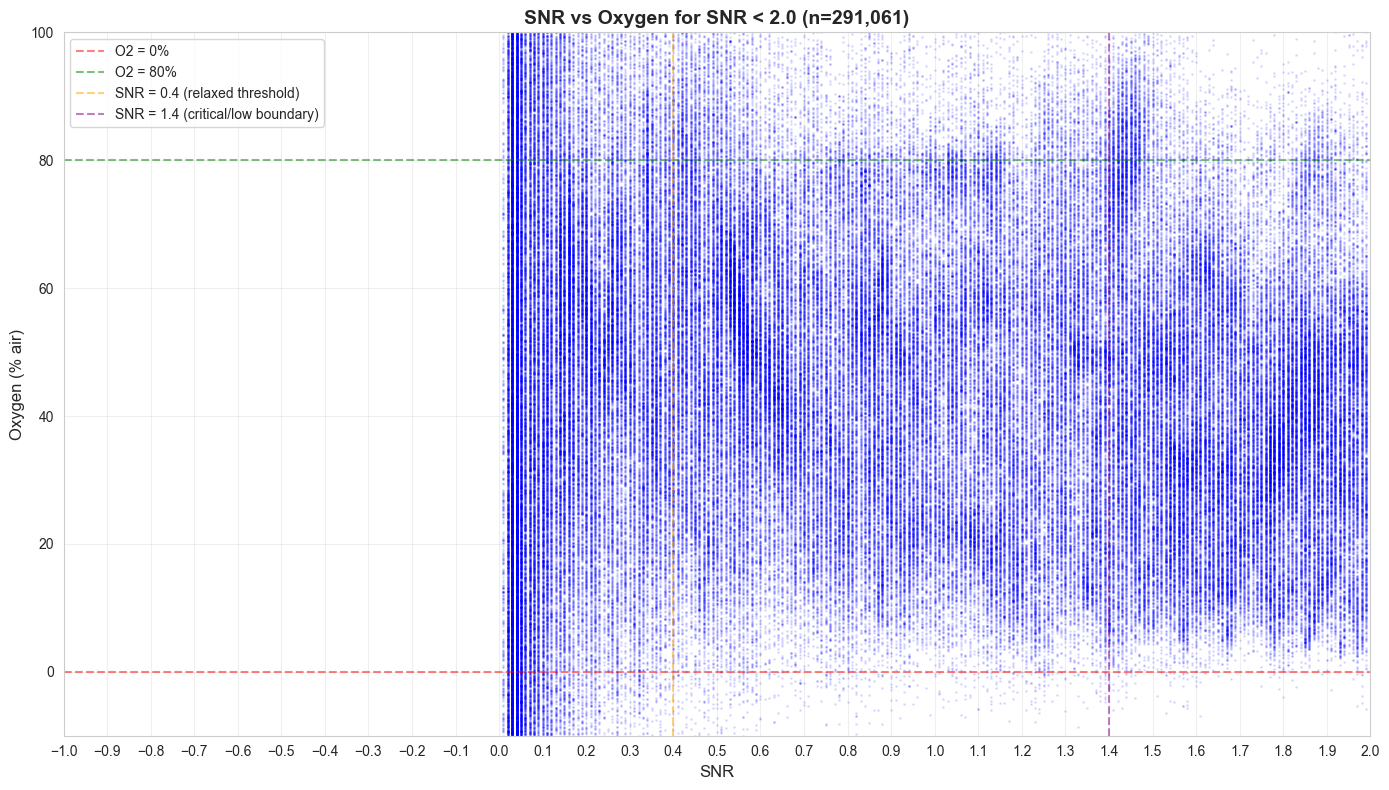

In [13]:
# Filter data to plotting range: -1 ≤ SNR ≤ 2, -10 ≤ O2 ≤ 100
df_plot_range = df_low_snr[(df_low_snr['snr'] >= -1) & (df_low_snr['snr'] <= 2) &
                           (df_low_snr['oxygen_pct_air'] >= -10) & (df_low_snr['oxygen_pct_air'] <= 100)].copy()

# Count data outside the plotting range
outside_snr_low = len(df_low_snr[df_low_snr['snr'] < -1])
outside_snr_high = len(df_low_snr[df_low_snr['snr'] > 2])
outside_o2_low = len(df_low_snr[df_low_snr['oxygen_pct_air'] < -10])
outside_o2_high = len(df_low_snr[df_low_snr['oxygen_pct_air'] > 100])

print(f"Data WITHIN plotting range (-1 ≤ SNR ≤ 2, -10 ≤ O2 ≤ 100): {len(df_plot_range):,}")
print(f"Data OUTSIDE plotting range:")
print(f"  - SNR < -1: {outside_snr_low:,}")
print(f"  - SNR > 2: {outside_snr_high:,}")
print(f"  - O2 < -10%: {outside_o2_low:,}")
print(f"  - O2 > 100%: {outside_o2_high:,}")
print(f"  - Total outside: {len(df_low_snr) - len(df_plot_range):,} ({(len(df_low_snr) - len(df_plot_range))/len(df_low_snr)*100:.1f}%)")

# Create scatter plot
plt.figure(figsize=(14, 8))

plt.scatter(df_plot_range['snr'], df_plot_range['oxygen_pct_air'], 
            alpha=0.1, s=1, c='blue')

plt.xlabel('SNR', fontsize=12)
plt.ylabel('Oxygen (% air)', fontsize=12)
plt.title(f'SNR vs Oxygen for SNR < 2.0 (n={len(df_plot_range):,})', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Set axis limits and ticks
plt.xlim(-1, 2)
plt.ylim(-10, 100)
plt.xticks(np.arange(-1, 2.1, 0.1))

# Add reference lines
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='O2 = 0%')
plt.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='O2 = 80%')
plt.axvline(x=0.4, color='orange', linestyle='--', alpha=0.5, label='SNR = 0.4 (relaxed threshold)')
plt.axvline(x=1.4, color='purple', linestyle='--', alpha=0.5, label='SNR = 1.4 (critical/low boundary)')

plt.legend(loc='best')
plt.tight_layout()
plt.show()

## Analysis Summary

The plot above shows SNR vs Oxygen for the target range:
- **SNR**: -1 to 2 (tick marks every 0.1)
- **O2**: -10% to 100% air saturation

Data outside this viewing window is reported above.

In [14]:
# Additional analysis: Distribution within plotting range
print("Distribution within plotting range (-1 ≤ SNR ≤ 2, -10 ≤ O2 ≤ 100):")
print(f"\nSNR Statistics:")
print(f"  Mean: {df_plot_range['snr'].mean():.3f}")
print(f"  Median: {df_plot_range['snr'].median():.3f}")
print(f"  Std: {df_plot_range['snr'].std():.3f}")

print(f"\nO2 Statistics:")
print(f"  Mean: {df_plot_range['oxygen_pct_air'].mean():.2f}%")
print(f"  Median: {df_plot_range['oxygen_pct_air'].median():.2f}%")
print(f"  Std: {df_plot_range['oxygen_pct_air'].std():.2f}%")

print(f"\nData in valid QC range (0 ≤ O2 ≤ 80%, SNR ≥ 2.0): n/a (all data has SNR < 2.0)")
print(f"Data in valid O2 range (0 ≤ O2 ≤ 80%): {((df_plot_range['oxygen_pct_air'] >= 0) & (df_plot_range['oxygen_pct_air'] <= 80)).sum():,} ({((df_plot_range['oxygen_pct_air'] >= 0) & (df_plot_range['oxygen_pct_air'] <= 80)).sum()/len(df_plot_range)*100:.1f}%)")

Distribution within plotting range (-1 ≤ SNR ≤ 2, -10 ≤ O2 ≤ 100):

SNR Statistics:
  Mean: 0.885
  Median: 0.840
  Std: 0.628

O2 Statistics:
  Mean: 44.77%
  Median: 44.50%
  Std: 23.67%

Data in valid QC range (0 ≤ O2 ≤ 80%, SNR ≥ 2.0): n/a (all data has SNR < 2.0)
Data in valid O2 range (0 ≤ O2 ≤ 80%): 262,612 (90.2%)


## Summary Statistics by SNR Range

In [15]:
# Break down by SNR ranges
ranges = [
    ('SNR < 0.4', df_low_snr[df_low_snr['snr'] < 0.4]),
    ('0.4 ≤ SNR < 1.4', df_low_snr[(df_low_snr['snr'] >= 0.4) & (df_low_snr['snr'] < 1.4)]),
    ('1.4 ≤ SNR < 2.0', df_low_snr[(df_low_snr['snr'] >= 1.4) & (df_low_snr['snr'] < 2.0)])
]

summary = []
for label, subset in ranges:
    if len(subset) > 0:
        summary.append({
            'SNR Range': label,
            'Count': f"{len(subset):,}",
            'O2 Mean': f"{subset['oxygen_pct_air'].mean():.1f}%",
            'O2 Std': f"{subset['oxygen_pct_air'].std():.1f}%",
            'O2 Min': f"{subset['oxygen_pct_air'].min():.1f}%",
            'O2 Max': f"{subset['oxygen_pct_air'].max():.1f}%",
            '% in 0-80%': f"{((subset['oxygen_pct_air'] >= 0) & (subset['oxygen_pct_air'] <= 80)).sum() / len(subset) * 100:.1f}%"
        })

summary_df = pd.DataFrame(summary)
summary_df

,SNR Range,Count,O2 Mean,O2 Std,O2 Min,O2 Max,% in 0-80%
0,SNR < 0.4,"571,245",-21.9%,20249.9%,-7749635.0%,9796958.0%,12.5%
1,0.4 ≤ SNR < 1.4,"126,406",50.8%,34.6%,-893.9%,325.7%,88.8%
2,1.4 ≤ SNR < 2.0,"85,493",44.1%,28.3%,-535.6%,255.0%,92.4%


## SNR Bucket Analysis: O2 Range Quality

This section analyzes which SNR values produce the highest percentage of O2 measurements within the extended range of -20 to 120% air saturation.

We create 0.1 SNR increments (buckets) and calculate:
- **% In Range**: Percentage of O2 values within -20 to 120%
- **% Out of Range**: Percentage of O2 values outside this range

In [16]:
# Create SNR buckets with 0.1 increments
snr_min = -1.0
snr_max = 10.0  # Covers most practical SNR values
bin_width = 0.1

# Create bins
bins = np.arange(snr_min, snr_max + bin_width, bin_width)

# Calculate percentage in range (-20 to 120%) for each SNR bin
print("Calculating percentages for each SNR bucket...")
results = []
for i in range(len(bins)-1):
    bin_lower = bins[i]
    bin_upper = bins[i+1]
    bin_label = f"{bin_lower:.1f}-{bin_upper:.1f}"
    
    # Select data in this bin
    subset = df[(df['snr'] >= bin_lower) & (df['snr'] < bin_upper)]
    
    if len(subset) > 0:
        in_range = ((subset['oxygen_pct_air'] >= -20) & (subset['oxygen_pct_air'] <= 120)).sum()
        pct_in_range = (in_range / len(subset)) * 100
        pct_out_range = 100 - pct_in_range
        
        results.append({
            'SNR_bin': bin_label,
            'SNR_lower': bin_lower,
            'count': len(subset),
            'pct_in_range': pct_in_range,
            'pct_out_range': pct_out_range
        })

results_df = pd.DataFrame(results)

# Filter to only show bins with at least 100 measurements (to avoid noise from sparse bins)
min_count = 100
results_df_filtered = results_df[results_df['count'] >= min_count].copy()

print(f"\nTotal SNR bins: {len(results_df)}")
print(f"Bins with >={min_count} measurements: {len(results_df_filtered)}")
print(f"SNR range covered: {results_df_filtered['SNR_lower'].min():.1f} to {results_df_filtered['SNR_lower'].max():.1f}\n")

# Find the SNR bucket with the highest percentage in range
best_bucket = results_df_filtered.loc[results_df_filtered['pct_in_range'].idxmax()]
print(f"SNR bucket with HIGHEST % in range (-20 to 120%):")
print(f"  SNR Range: {best_bucket['SNR_bin']}")
print(f"  Count: {best_bucket['count']:,.0f}")
print(f"  % in range: {best_bucket['pct_in_range']:.2f}%")
print(f"  % out of range: {best_bucket['pct_out_range']:.2f}%\n")

# Show top 10 buckets
print("Top 10 SNR buckets by % in range:")
results_df_filtered.nlargest(10, 'pct_in_range')[['SNR_bin', 'count', 'pct_in_range', 'pct_out_range']]

Calculating percentages for each SNR bucket...

Total SNR bins: 101
Bins with >=100 measurements: 101
SNR range covered: -1.0 to 9.9

SNR bucket with HIGHEST % in range (-20 to 120%):
  SNR Range: 9.1-9.2
  Count: 17,999
  % in range: 99.59%
  % out of range: 0.41%

Top 10 SNR buckets by % in range:


,SNR_bin,count,pct_in_range,pct_out_range
92,9.1-9.2,17999,99.594422,0.405578
95,9.4-9.5,17925,99.581590,0.418410
94,9.3-9.4,18074,99.524178,0.475822
93,9.2-9.3,18336,99.487347,0.512653
96,9.5-9.6,18082,99.485676,0.514324
97,9.6-9.7,18140,99.454245,0.545755
91,9.0-9.1,18474,99.377504,0.622496
75,7.4-7.5,18081,99.281013,0.718987
42,4.1-4.2,21451,99.263438,0.736562
54,5.3-5.4,22727,99.260791,0.739209


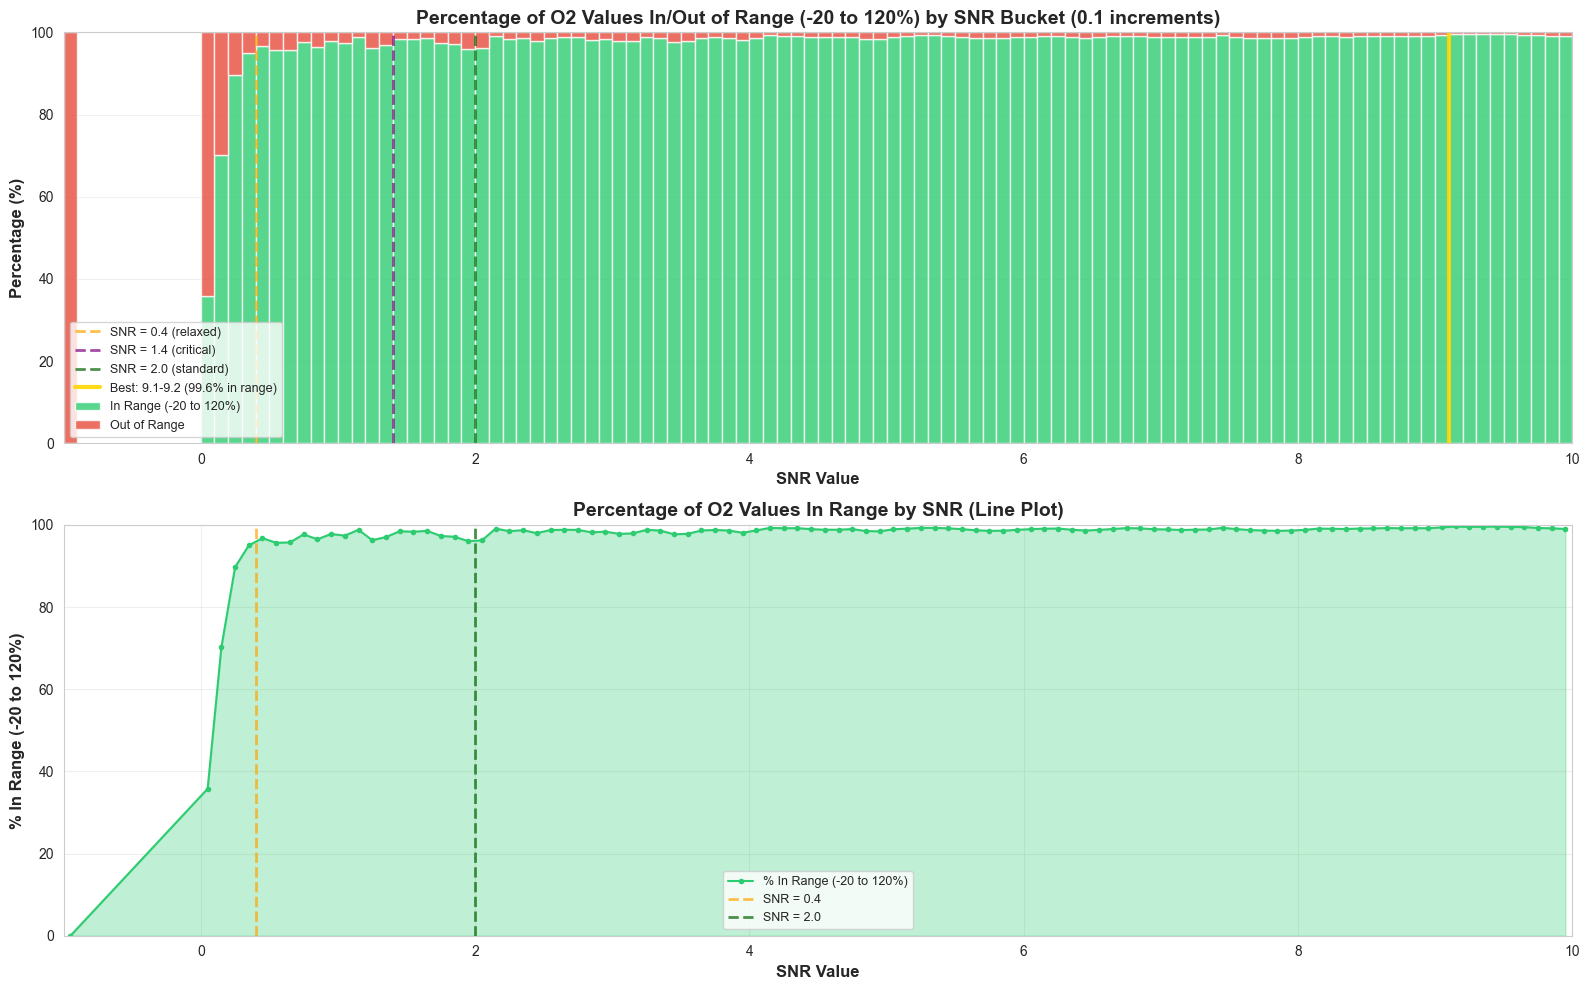

In [17]:
# Create the bucket plot visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Stacked bar chart showing in-range vs out-of-range percentages
ax1.bar(results_df_filtered['SNR_lower'], results_df_filtered['pct_in_range'],
        width=bin_width, align='edge', label='In Range (-20 to 120%)', color='#2ecc71', alpha=0.8)
ax1.bar(results_df_filtered['SNR_lower'], results_df_filtered['pct_out_range'],
        bottom=results_df_filtered['pct_in_range'], width=bin_width, align='edge',
        label='Out of Range', color='#e74c3c', alpha=0.8)

ax1.set_xlabel('SNR Value', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax1.set_title('Percentage of O2 Values In/Out of Range (-20 to 120%) by SNR Bucket (0.1 increments)',
              fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xlim(snr_min, results_df_filtered['SNR_lower'].max() + bin_width)
ax1.set_ylim(0, 100)

# Add reference lines
ax1.axvline(x=0.4, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='SNR = 0.4 (relaxed)')
ax1.axvline(x=1.4, color='purple', linestyle='--', linewidth=2, alpha=0.7, label='SNR = 1.4 (critical)')
ax1.axvline(x=2.0, color='darkgreen', linestyle='--', linewidth=2, alpha=0.7, label='SNR = 2.0 (standard)')

# Highlight the best bucket
ax1.axvline(x=best_bucket['SNR_lower'], color='gold', linestyle='-', linewidth=3, alpha=0.9,
            label=f"Best: {best_bucket['SNR_bin']} ({best_bucket['pct_in_range']:.1f}% in range)")

ax1.legend(loc='best', fontsize=9)

# Plot 2: Line plot showing percentage in range vs SNR
ax2.plot(results_df_filtered['SNR_lower'] + bin_width/2, results_df_filtered['pct_in_range'],
         marker='o', markersize=3, linewidth=1.5, color='#2ecc71', label='% In Range (-20 to 120%)')
ax2.fill_between(results_df_filtered['SNR_lower'] + bin_width/2, results_df_filtered['pct_in_range'],
                  alpha=0.3, color='#2ecc71')

ax2.set_xlabel('SNR Value', fontsize=12, fontweight='bold')
ax2.set_ylabel('% In Range (-20 to 120%)', fontsize=12, fontweight='bold')
ax2.set_title('Percentage of O2 Values In Range by SNR (Line Plot)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(snr_min, results_df_filtered['SNR_lower'].max() + bin_width)
ax2.set_ylim(0, 100)

# Add reference lines
ax2.axvline(x=0.4, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='SNR = 0.4')
ax2.axvline(x=2.0, color='darkgreen', linestyle='--', linewidth=2, alpha=0.7, label='SNR = 2.0')

ax2.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

## SNR Bucket Analysis: Standard QC Range (0-80%)

This section analyzes which SNR values produce the highest percentage of O2 measurements within the **standard QC range of 0 to 80%** air saturation (the range used in the pipeline filtering).

We create 0.1 SNR increments (buckets) and calculate:
- **% In Range**: Percentage of O2 values within 0 to 80%
- **% Out of Range**: Percentage of O2 values outside this range

In [18]:
# Calculate percentage in range (0 to 80%) for each SNR bin
print("Calculating percentages for each SNR bucket (0-80% range)...")
results_qc = []
for i in range(len(bins)-1):
    bin_lower = bins[i]
    bin_upper = bins[i+1]
    bin_label = f"{bin_lower:.1f}-{bin_upper:.1f}"
    
    # Select data in this bin
    subset = df[(df['snr'] >= bin_lower) & (df['snr'] < bin_upper)]
    
    if len(subset) > 0:
        in_range_qc = ((subset['oxygen_pct_air'] >= 0) & (subset['oxygen_pct_air'] <= 80)).sum()
        pct_in_range_qc = (in_range_qc / len(subset)) * 100
        pct_out_range_qc = 100 - pct_in_range_qc
        
        results_qc.append({
            'SNR_bin': bin_label,
            'SNR_lower': bin_lower,
            'count': len(subset),
            'pct_in_range': pct_in_range_qc,
            'pct_out_range': pct_out_range_qc
        })

results_qc_df = pd.DataFrame(results_qc)

# Filter to only show bins with at least 100 measurements
results_qc_filtered = results_qc_df[results_qc_df['count'] >= min_count].copy()

print(f"\nTotal SNR bins: {len(results_qc_df)}")
print(f"Bins with >={min_count} measurements: {len(results_qc_filtered)}")
print(f"SNR range covered: {results_qc_filtered['SNR_lower'].min():.1f} to {results_qc_filtered['SNR_lower'].max():.1f}\n")

# Find the SNR bucket with the highest percentage in range
best_bucket_qc = results_qc_filtered.loc[results_qc_filtered['pct_in_range'].idxmax()]
print(f"SNR bucket with HIGHEST % in QC range (0 to 80%):")
print(f"  SNR Range: {best_bucket_qc['SNR_bin']}")
print(f"  Count: {best_bucket_qc['count']:,.0f}")
print(f"  % in range: {best_bucket_qc['pct_in_range']:.2f}%")
print(f"  % out of range: {best_bucket_qc['pct_out_range']:.2f}%\n")

# Show top 10 buckets
print("Top 10 SNR buckets by % in QC range (0-80%):")
results_qc_filtered.nlargest(10, 'pct_in_range')[['SNR_bin', 'count', 'pct_in_range', 'pct_out_range']]

Calculating percentages for each SNR bucket (0-80% range)...

Total SNR bins: 101
Bins with >=100 measurements: 101
SNR range covered: -1.0 to 9.9

SNR bucket with HIGHEST % in QC range (0 to 80%):
  SNR Range: 9.0-9.1
  Count: 18,474
  % in range: 97.69%
  % out of range: 2.31%

Top 10 SNR buckets by % in QC range (0-80%):


,SNR_bin,count,pct_in_range,pct_out_range
91,9.0-9.1,18474,97.694057,2.305943
75,7.4-7.5,18081,97.610752,2.389248
88,8.7-8.8,19281,97.609045,2.390955
89,8.8-8.9,18993,97.599115,2.400885
87,8.6-8.7,19293,97.574250,2.425750
86,8.5-8.6,19782,97.477505,2.522495
90,8.9-9.0,18918,97.473306,2.526694
95,9.4-9.5,17925,97.472803,2.527197
94,9.3-9.4,18074,97.427244,2.572756
93,9.2-9.3,18336,97.398560,2.601440


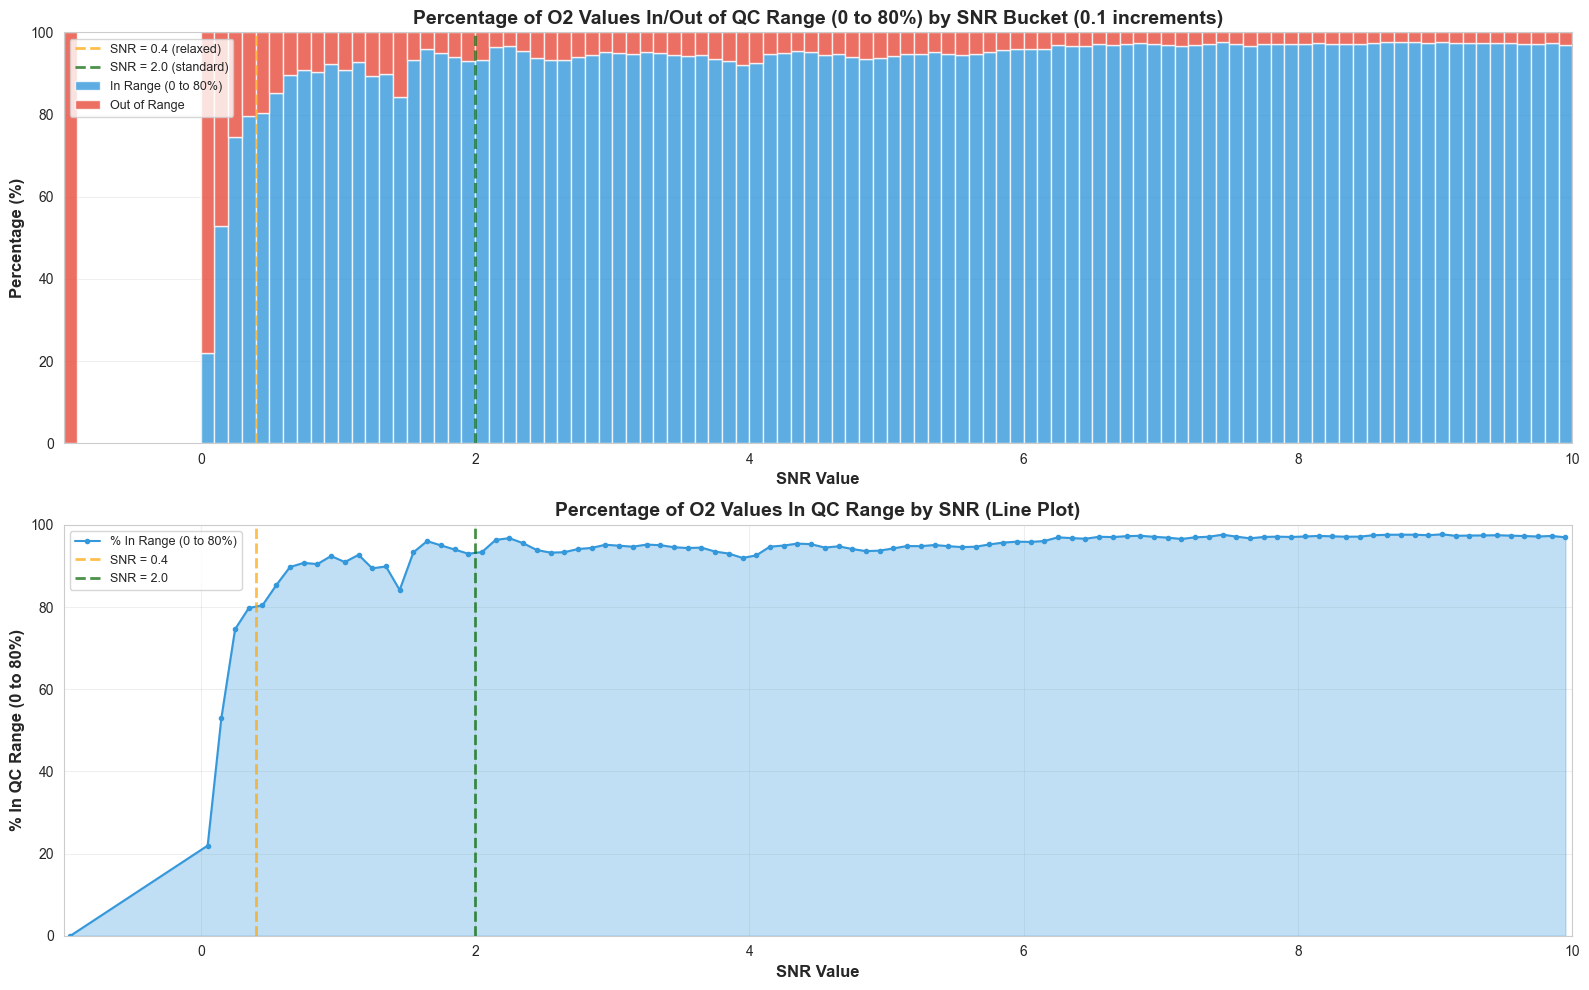

In [19]:
# Cell #17
# Depends on: 16

# Create the bucket plot visualization for QC range (0-80%)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Stacked bar chart showing in-range vs out-of-range percentages
ax1.bar(results_qc_filtered['SNR_lower'], results_qc_filtered['pct_in_range'],
        width=bin_width, align='edge', label='In Range (0 to 80%)', color='#3498db', alpha=0.8)
ax1.bar(results_qc_filtered['SNR_lower'], results_qc_filtered['pct_out_range'],
        bottom=results_qc_filtered['pct_in_range'], width=bin_width, align='edge',
        label='Out of Range', color='#e74c3c', alpha=0.8)

ax1.set_xlabel('SNR Value', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax1.set_title('Percentage of O2 Values In/Out of QC Range (0 to 80%) by SNR Bucket (0.1 increments)',
              fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xlim(snr_min, results_qc_filtered['SNR_lower'].max() + bin_width)
ax1.set_ylim(0, 100)

# Add reference lines (removed SNR 1.4 and best bucket)
ax1.axvline(x=0.4, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='SNR = 0.4 (relaxed)')
ax1.axvline(x=2.0, color='darkgreen', linestyle='--', linewidth=2, alpha=0.7, label='SNR = 2.0 (standard)')

ax1.legend(loc='best', fontsize=9)

# Plot 2: Line plot showing percentage in range vs SNR
ax2.plot(results_qc_filtered['SNR_lower'] + bin_width/2, results_qc_filtered['pct_in_range'],
         marker='o', markersize=3, linewidth=1.5, color='#3498db', label='% In Range (0 to 80%)')
ax2.fill_between(results_qc_filtered['SNR_lower'] + bin_width/2, results_qc_filtered['pct_in_range'],
                  alpha=0.3, color='#3498db')

ax2.set_xlabel('SNR Value', fontsize=12, fontweight='bold')
ax2.set_ylabel('% In QC Range (0 to 80%)', fontsize=12, fontweight='bold')
ax2.set_title('Percentage of O2 Values In QC Range by SNR (Line Plot)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(snr_min, results_qc_filtered['SNR_lower'].max() + bin_width)
ax2.set_ylim(0, 100)

# Add reference lines (removed SNR 1.4 and best bucket)
ax2.axvline(x=0.4, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='SNR = 0.4')
ax2.axvline(x=2.0, color='darkgreen', linestyle='--', linewidth=2, alpha=0.7, label='SNR = 2.0')

ax2.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

## Export Plot Data to Excel

Export X and Y values from all plots to Excel files for external visualization.

In [21]:
# Cell #18
# Depends on: 6, 13, 16

# Create output directory
output_dir = PROJECT_ROOT / 'Output' / 'QC_Analysis'
output_dir.mkdir(parents=True, exist_ok=True)

print("Exporting plot data to Excel files...")

# === Export 1: Scatter Plot Data (SNR vs O2, filtered to plotting range) ===
scatter_export = df_plot_range[['snr', 'oxygen_pct_air']].copy()
scatter_export.columns = ['SNR (X)', 'Oxygen_Pct_Air (Y)']
scatter_file = output_dir / 'ScatterPlot_SNR_vs_O2.xlsx'
scatter_export.to_excel(scatter_file, index=False, sheet_name='SNR_vs_O2')
print(f"  1. Scatter plot data: {scatter_file}")
print(f"     Rows: {len(scatter_export):,}")

# === Export 2: Bucket Analysis (-20 to 120% range) ===
bucket_extended = results_df_filtered[['SNR_lower', 'pct_in_range', 'pct_out_range', 'count']].copy()
bucket_extended.columns = ['SNR_Bucket_Lower (X)', 'Pct_In_Range_-20_to_120 (Y)', 'Pct_Out_Range (Y)', 'Measurement_Count']

# Add midpoint for line plots
bucket_extended['SNR_Bucket_Midpoint (X)'] = bucket_extended['SNR_Bucket_Lower (X)'] + bin_width/2

bucket_extended_file = output_dir / 'BucketAnalysis_Extended_Range.xlsx'
bucket_extended.to_excel(bucket_extended_file, index=False, sheet_name='Extended_Range')
print(f"  2. Bucket analysis (-20 to 120%): {bucket_extended_file}")
print(f"     Rows: {len(bucket_extended):,}")

# === Export 3: Bucket Analysis (0-80% QC range) ===
bucket_qc = results_qc_filtered[['SNR_lower', 'pct_in_range', 'pct_out_range', 'count']].copy()
bucket_qc.columns = ['SNR_Bucket_Lower (X)', 'Pct_In_Range_0_to_80 (Y)', 'Pct_Out_Range (Y)', 'Measurement_Count']

# Add midpoint for line plots
bucket_qc['SNR_Bucket_Midpoint (X)'] = bucket_qc['SNR_Bucket_Lower (X)'] + bin_width/2

bucket_qc_file = output_dir / 'BucketAnalysis_QC_Range.xlsx'
bucket_qc.to_excel(bucket_qc_file, index=False, sheet_name='QC_Range')
print(f"  3. Bucket analysis (0-80% QC): {bucket_qc_file}")
print(f"     Rows: {len(bucket_qc):,}")

print("All plot data exported successfully!")
print(f"Output directory: {output_dir}")

Exporting plot data to Excel files...
  1. Scatter plot data: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\QC_Analysis\ScatterPlot_SNR_vs_O2.xlsx
     Rows: 291,061
  2. Bucket analysis (-20 to 120%): c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\QC_Analysis\BucketAnalysis_Extended_Range.xlsx
     Rows: 101
  3. Bucket analysis (0-80% QC): c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\QC_Analysis\BucketAnalysis_QC_Range.xlsx
     Rows: 101
All plot data exported successfully!
Output directory: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\QC_Analysis
